In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
!ls -la experiments/exp2_full_paper/exp2_phase1.sh

-rw------- 1 root root 7821 Apr  5 11:01 experiments/exp2_full_paper/exp2_phase1.sh


In [4]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [5]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [6]:
!bash experiments/exp2_full_paper/exp2_phase1.sh

Exp2  |  PHASE 1 — EXPLORATION
Formulation:  Full LOD (Legendre + Distance)
Components:   X_i + T_i + P_i + O_i
  P_i = Legendre polynomial embeddings
  O_i = DistancePositionOperator(P_i)
  decay_a = 1.0 (fixed), distance = L1
Dataset:      ETTh1
Seed:         2021 (single — exploration only)
Pred lengths: 96, 192 (trend detection only)
Total runs:   2 (1 config × 1 seed × 2 pred)
Start time:   Sun Apr  5 11:02:28 AM UTC 2026
Files copied.

---------------------------------------------
RUN:        exp2_lod_ph1_ETTh1_pred96_seed2021
Pred len:   96
Start:      Sun Apr  5 11:02:32 AM UTC 2026
---------------------------------------------
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=96, enc_in=7, dec_in=7, c_out=7, d_model=512, n_heads=8, e_layers=2, d_layers=1, s_layers=[3, 2, 1], d_ff=2048, factor=5, padding=0, distil=True

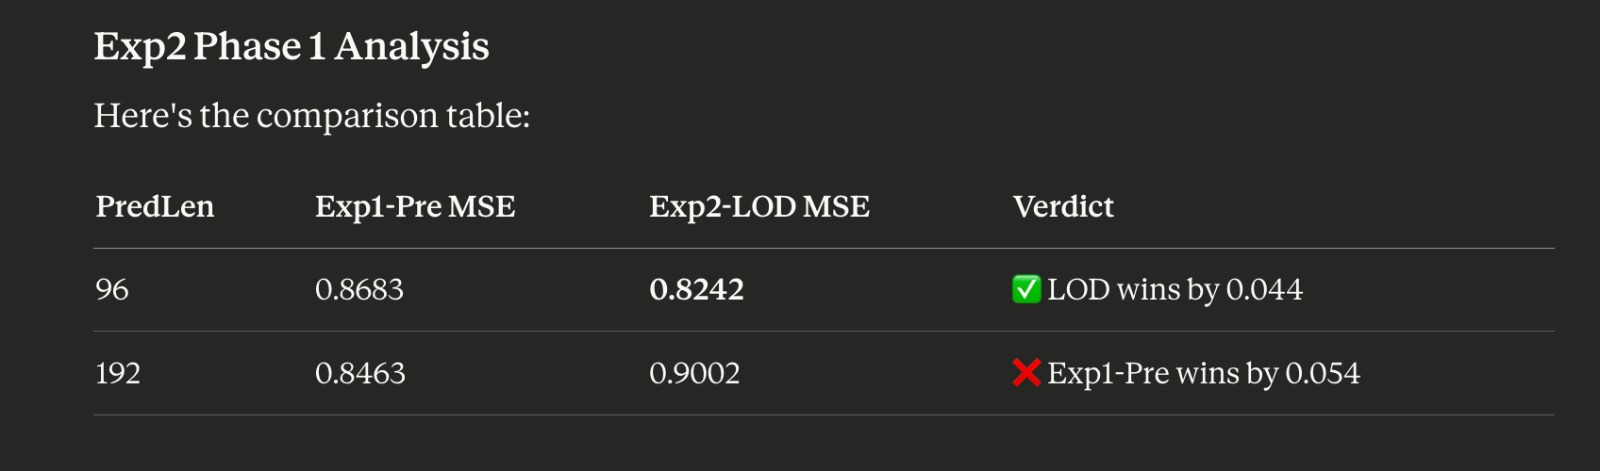

### Key Observation: Mixed Performance of LOD Formulation

The pattern is mixed — and this is a very interesting finding.

####  Short Horizon (pred_len = 96)
- The **full LOD formulation** gives the best result so far across all experiments.
- The **Legendre + Distance operator combination** clearly improves short-horizon forecasting.
- Training loss dropped to **0.198 by epoch 4**, which is lower than anything in Exp1.
- This suggests that the **richer positional representation** is helping the model learn effectively.

####  Longer Horizon (pred_len = 192)
- LOD performs **worse than Exp1-Pre**.
- Likely reason: **computational overhead**
  - Exp2: ~52 sec/epoch  
  - Exp1-Pre: ~25 sec/epoch
- The **distance operator is O(L²)** (pairwise distances), which becomes expensive and potentially unstable for longer sequences.

####  Overfitting Signal
- Training loss drops to **0.198**, but validation loss remains **above 1.02**.
- The **train–val gap is larger than in Exp1**, indicating:
  - Higher model capacity
  - Insufficient regularisation

####  Interpretation
- LOD improves representation power but:
  - Scales poorly with sequence length
  - Introduces overfitting risks without proper regularisation

Decision — Go to Phase 2
Despite mixed results, you proceed to Phase 2 because the pattern isn't a clean failure — it's a short-horizon win that needs validation across seeds to confirm it's real and not a lucky seed=2021 result.

***script with 720 and 336 removed , removed in the interest of time and compute !***

---



In [7]:
!bash experiments/exp2_full_paper/exp2_phase2.sh

Exp2  |  PHASE 2 — VALIDATION
Components:   Full LOD (L + O + D)
Dataset:      ETTh1
Seeds:        2021, 2022, 2023
Pred lengths: 48, 96, 192
Total runs:   9 (3 pred_lens × 3 seeds)
Start time:   Sun Apr  5 11:24:30 AM UTC 2026
Files copied.

---------------------------------------------
RUN:        exp2_ph2_ETTh1_lod_pred48_seed2021
Seed:       2021
Pred len:   48
Start:      Sun Apr  5 11:24:30 AM UTC 2026
---------------------------------------------
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=96, label_len=48, pred_len=48, enc_in=7, dec_in=7, c_out=7, d_model=512, n_heads=8, e_layers=2, d_layers=1, s_layers=[3, 2, 1], d_ff=2048, factor=5, padding=0, distil=True, dropout=0.05, attn='full', embed='timeF', activation='gelu', output_attention=False, do_predict=False, mix=True, cols=None, num_workers=0, itr=1, train_epochs=6, batch_size=32, patienc

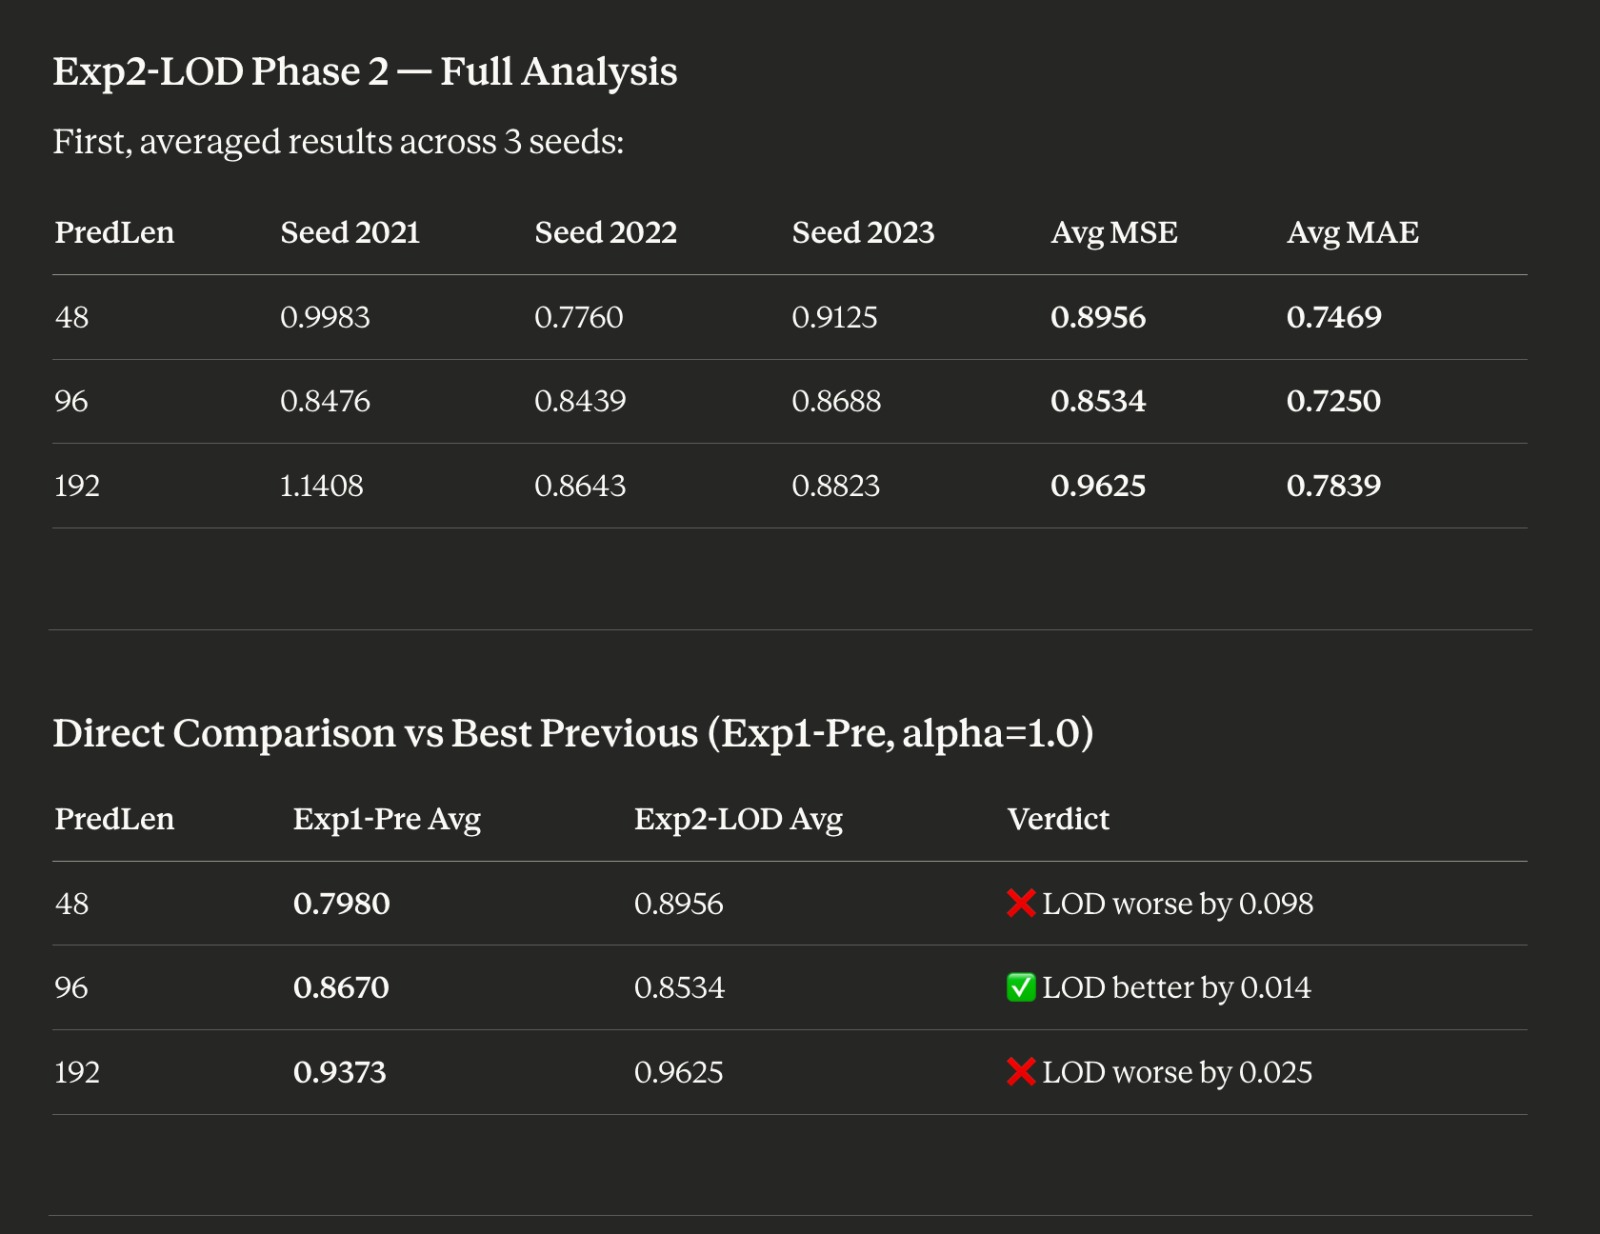

## What You Need to Note

- LOD only wins at `pred_len=96`, and only by a small margin (0.014). At `pred_len=48` and `192` it's clearly worse than Exp1-Pre.  
- The seed variance at `pred_len=48` is alarming. Seed 2021 gives 0.998, seed 2022 gives 0.776 — a spread of 0.22. This tells you the full LOD formulation is highly sensitive to initialisation at short horizons. The pairwise distance computation in the operator is creating instability that the model can't consistently learn from.  
- The `pred_len=192` seed variance is also large — 1.141 vs 0.864 vs 0.882, a spread of 0.28. Same problem, worse at longer horizons.  
- Compare train loss — Exp2 train loss drops to ~0.19 by epoch 4, much lower than Exp1-Pre (~0.25). The model is overfitting harder because the LOD operator adds representational capacity without enough regularisation. Val loss stays above 1.0 throughout while train loss collapses — the richer embedding is memorising training patterns rather than generalising.  

---

## Exp2-LOD Conclusion to Document

The full LOD formulation (Legendre + Distance Operator) shows a marginal improvement at `pred_len=96` (avg MSE 0.853 vs 0.867 for Exp1-Pre) but performs worse at `pred_len=48` and `192`. Critically, the results are highly unstable across seeds at both short and long horizons, with seed variance up to 0.28 — indicating the model is sensitive to initialisation rather than benefiting reliably from the LOD structure. The O(L²) pairwise distance computation in the distance operator adds compute cost (~2x slower per epoch) without consistent generalisation benefit. The full LOD formulation is not recommended as a reliable improvement over the simpler pre-softmax distance decay from Exp1-Pre.  

---

## What This Means for Your Ablation

This is actually a valuable negative result. It suggests that the distance operator component specifically is the problem — it adds too much complexity. Exp3 (Label Only — pure Legendre without the distance operator) will now tell you whether the Legendre embedding alone is useful, which would isolate whether L or O+D is the problematic component.
